# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)



## 1. Question

Research question: Which visible pages under-capture clicks relative to what
their search position would predict, so a content editor can prioritise which
pages to review first?

Lane: CTR / Engagement Opportunity Scoring.

The decision it supports: an editor has limited time and can only review a
handful of pages per cycle. This work produces a ranked queue of pages that
appear to under-earn clicks for their position tier, as decision-support for
where to focus a title/snippet/content review — not a guarantee that any page
will improve.

## 2. Data

Data source: the FlyRank ML Internship warehouse release (Hugging Face, gated).

Tables used: fact_content_daily_performance - one row per page per day,
carrying Google Search Console (GSC) search metrics and Google Analytics 4
(GA4) engagement metrics.

Grain: one row = one content page on one day.

Time window: I developed and evaluated on month=2026-03. Within that month I
split by client (client-holdout), so the test clients were never seen during
training. I did not run a separate evaluation on the final month (June 2026);
a time-based test on that held-out month is noted as future work.

What I excluded and why:
- Rows without GSC search data (~63% of the month): no clicks or impressions
  means no CTR to score, so they cannot support this lane.
- Rows without GA4 data: my engagement features come from GA4, so I restricted
  to GA4-available rows (~180,000 pages).
- Low-visibility pages (fewer than 100 impressions): their CTR is too noisy to
  trust as a signal.

Public-safe: all client and page identifiers are salted hashes. I report no
client names, domains, URLs, or raw search queries.

## 3. Methodology

Task framing: a regression / scoring task. I predict the CTR gap for each page
and rank pages by it, so the largest under-earners sit at the top of an
editor's review queue.

Label (target) definition:
- For each position tier (top_3, page_1, page_2, deep), I compute the expected
  CTR as the mean CTR of pages in that tier.
- ctr_gap = expected_ctr - actual_ctr. A larger positive gap means the page
  earns fewer clicks than its position peers, i.e. it under-earns.
- Tier means are computed on TRAINING data only, then applied to the test set,
  so the target does not leak test information into training.

Features (all from GA4 on-site engagement, knowable independently of the
search-side CTR being predicted):
sessions_organic, ga4_pageviews, ga4_engaged_sessions, ga4_sessions,
scroll_events, ga4_users, ga4_total_engagement_sec.

Leakage checks:
- Excluded ctr and gsc_clicks (the target is built from these - circular).
- Excluded expected_ctr and ctr_gap (they are the target).
- Excluded avg_position / position_tier (the target is defined relative to
  these tiers - circular).
- Confirmed every retained feature correlates only modestly with the target
  (roughly 0.1-0.36 in magnitude, none near +/-1), consistent with a real,
  non-leaky signal.

Baseline: a transparent hand rule that scores each page directly by the CTR
gap and ranks worst-first (my Week-4 baseline).

Validation design: client-holdout using GroupShuffleSplit - whole clients are
held out for testing, so the model is evaluated on brands it never trained on.
This tests generalisation to unseen clients rather than memorised client quirks.

Models compared: Linear Regression, K-Nearest Neighbors Regressor, and Decision
Tree Regressor, scored on MAE and R2, with the best carried forward.

## 4. Results (vs baseline)

Model comparison on the client-holdout split (test = unseen clients):

| Model             | MAE     | R2      |
|-------------------|---------|---------|
| Linear Regression | 0.00408 | 0.106   |
| KNN               | 0.00423 | 0.038   |
| Decision Tree     | 0.00450 | -0.252  |

Linear Regression performed best (lowest error, highest R2). The Decision Tree
had a negative R2, meaning it did worse than simply predicting the average on
unseen clients. It overfit the training clients. The simplest model generalised
best.

An R2 of about 0.11 is modest, but expected. I am predicting a noisy
web-behaviour signal from engagement features alone, and I deliberately
excluded the columns (clicks, CTR) that would inflate R2 without being usable
at decision time.

Ranking quality (the metric that matters for the lane) is Precision@K: the
share of the top-K flagged pages that are genuine under-earners.

| K   | Model | Baseline |
|-----|-------|----------|
| 20  | 0.800 | 1.000    |
| 50  | 0.880 | 1.000    |
| 100 | 0.890 | 1.000    |

The baseline scores 1.000 by construction. It ranks pages by the actual CTR
gap, which is the answer itself, so it cannot be used to find under-earners
before their CTR is known. My model ranks using engagement signals only, never
seeing CTR, and still places about 88% genuine under-earners in its top 50.
That is the useful, honest result: engagement behaviour alone predicts
under-earning well enough to build a review queue an editor can act on.

## 5. Limitations

- Observational, not causal. This work shows an association between low on-site
  engagement and a larger CTR gap. It does not prove a page under-earns for a
  fixable reason, and it does not prove that a rewrite will recover clicks.

- Modest explanatory power. The model explains only about 11% of the variation
  in the CTR gap (R2 ~0.11). Much of what drives under-earning (title and
  snippet quality, search intent) is not in the data, which is exactly what a
  human editor is meant to review.

- Small number of clients. The evaluation held out whole clients, but there are
  only about 29 clients, with 6 in the test set, so the held-out estimate is
  noisy.

- Single month, no time test. I developed and validated on March 2026 with a
  client-holdout split. I did not run a time-based test on the sealed final
  month (June 2026); that is future work.

- Decision-support only. The output is a prioritised review queue, not an
  automated action and not an outcome guarantee.

All claims in this paper use safe language: observed, measured, directional,
decision-support.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The model scores every page by its predicted CTR gap and produces a ranked
review queue (written to work/outputs/capstone_action_queue.csv). An editor
works down the list from the top.

Reason codes and actions:
- LOW_CTR_FOR_POSITION -> review_title_and_snippet: the page earns fewer clicks
  than expected for its position tier. Suggested review: the search title and
  meta description first, since those drive clicks at a fixed position.
- OK -> monitor: no predicted under-earning; no action, just keep watching.

What the top of the queue looks like:
- The highest-ranked page is a top_3 page that under-earns badly. A page ranking
  in the top 3 but getting few clicks is a strong title/snippet candidate,
  because it already has visibility and only the click-through is weak.
- Several flagged pages sit deep in the results. For these, a snippet rewrite
  alone may not help much, since low visibility (not just low CTR) limits them.
  They are flagged for review, not guaranteed wins.

Intended use and limits:
- Who: a content editor or SEO reviewer choosing which pages to look at first.
- For what: prioritising a limited review budget, as decision-support.
- Where it stops: the model does not say WHY a page under-earns or that a rewrite
  will fix it. A human must confirm each page before acting.

Human review and the no-go list:
- A person should check that a flagged page's low CTR is not simply due to it
  ranking for irrelevant queries (where a rewrite would not help).
- Nothing here should be auto-applied. No title or content change should be made
  without human review.

When the recommendations go stale:
- Re-run when the underlying search or engagement patterns shift (for example a
  new month of data, a Google ranking change, or a seasonal traffic swing).
  Falling precision on reviewed pages is the signal to retrain.

In [1]:
import pandas as pd, numpy as np
from google.colab import userdata
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import os

# load + rebuild (same pipeline)
HF_TOKEN = userdata.get('HF_TOKEN')
url = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03"
df = pd.read_parquet(url, storage_options={"token": HF_TOKEN})

d = df[df["gsc_data_available"] == True].copy()
d["ctr"] = d["gsc_clicks"] / d["gsc_impressions"]
d["avg_position"] = d["gsc_sum_position"] / d["gsc_impressions"]
d = d[d["gsc_impressions"] >= 100].copy()
d["position_tier"] = np.select(
    [d["avg_position"] <= 3, d["avg_position"] <= 10, d["avg_position"] <= 20],
    ["top_3","page_1","page_2"], default="deep")

base = d[d["ga4_data_available"] == True].copy()
features = ["sessions_organic","ga4_pageviews","ga4_engaged_sessions",
            "ga4_sessions","scroll_events","ga4_users","ga4_total_engagement_sec"]

# grouped split, train-only tier means
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, te_idx = next(gss.split(base, groups=base["client_hash_id"]))
train, test = base.iloc[tr_idx].copy(), base.iloc[te_idx].copy()
tier_means = train.groupby("position_tier")["ctr"].mean()
for part in (train, test):
    part["expected_ctr"] = part["position_tier"].map(tier_means)
    part["ctr_gap"] = part["expected_ctr"] - part["ctr"]

# train model, predict on ALL pages (for the action queue)
scaler = StandardScaler()
model = LinearRegression().fit(scaler.fit_transform(train[features]), train["ctr_gap"])

base["expected_ctr"] = base["position_tier"].map(tier_means)
base["predicted_gap"] = model.predict(scaler.transform(base[features]))

# reason code + action label
base["reason_code"] = np.where(base["predicted_gap"] > 0,
                               "LOW_CTR_FOR_POSITION", "OK")
base["action"] = np.where(base["predicted_gap"] > 0,
                          "review_title_and_snippet", "monitor")

# ranked action queue
queue = base.sort_values("predicted_gap", ascending=False)

os.makedirs("work/outputs", exist_ok=True)
queue[["content_hash_id","position_tier","gsc_impressions","predicted_gap",
       "reason_code","action"]].to_csv("work/outputs/capstone_action_queue.csv", index=False)

print("Top 10 ranked recommendations:")
queue[["content_hash_id","position_tier","gsc_impressions","predicted_gap",
       "reason_code","action"]].head(10)

Top 10 ranked recommendations:


,content_hash_id,position_tier,gsc_impressions,predicted_gap,reason_code,action
9654643,content_6982fdcd6a6b28f8,top_3,343,0.056090,LOW_CTR_FOR_POSITION,review_title_and_snippet
7395309,content_b116498610b4e6da,page_1,153,0.030105,LOW_CTR_FOR_POSITION,review_title_and_snippet
9119334,content_6982fdcd6a6b28f8,top_3,1255,0.014288,LOW_CTR_FOR_POSITION,review_title_and_snippet
9650820,content_5460a0e854602a47,deep,167,0.010218,LOW_CTR_FOR_POSITION,review_title_and_snippet
1417411,content_5460a0e854602a47,deep,735,0.009645,LOW_CTR_FOR_POSITION,review_title_and_snippet
9384800,content_67fe53778dee2a5d,deep,235,0.009047,LOW_CTR_FOR_POSITION,review_title_and_snippet
4265844,content_87bc70dbf26df4b9,deep,143,0.008854,LOW_CTR_FOR_POSITION,review_title_and_snippet
1694376,content_5460a0e854602a47,deep,816,0.008794,LOW_CTR_FOR_POSITION,review_title_and_snippet
3033681,content_6a33ac36a098edcd,deep,271,0.008754,LOW_CTR_FOR_POSITION,review_title_and_snippet
1614269,content_5460a0e854602a47,deep,554,0.008151,LOW_CTR_FOR_POSITION,review_title_and_snippet


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

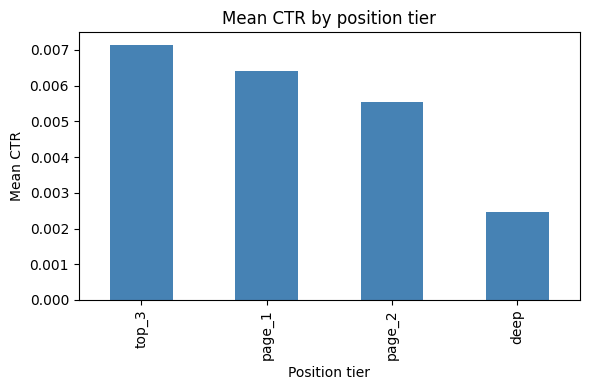

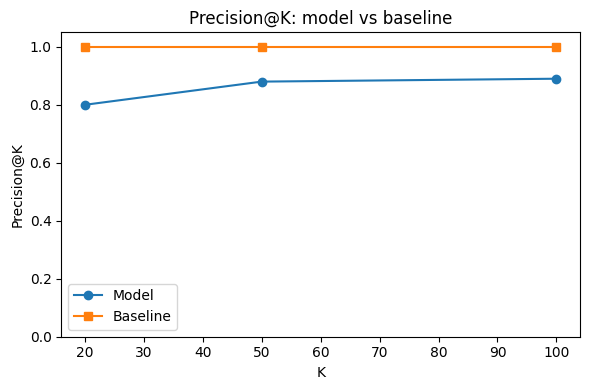

Saved: fig_ctr_by_tier.png, fig_precision_at_k.png


In [2]:
import matplotlib.pyplot as plt
import os
os.makedirs("work/outputs", exist_ok=True)

# Chart 1: CTR by position tier (the core signal — CTR falls as position worsens)
tier_order = ["top_3","page_1","page_2","deep"]
ctr_by_tier = base.groupby("position_tier")["ctr"].mean().reindex(tier_order)

plt.figure(figsize=(6,4))
ctr_by_tier.plot(kind="bar", color="steelblue")
plt.title("Mean CTR by position tier")
plt.ylabel("Mean CTR")
plt.xlabel("Position tier")
plt.tight_layout()
plt.savefig("work/outputs/fig_ctr_by_tier.png", dpi=120)
plt.show()

# Chart 2: model vs baseline Precision@K
import pandas as pd
prec = pd.DataFrame({
    "K": [20, 50, 100],
    "Model": [0.800, 0.880, 0.890],
    "Baseline": [1.000, 1.000, 1.000],
})
plt.figure(figsize=(6,4))
plt.plot(prec["K"], prec["Model"], marker="o", label="Model")
plt.plot(prec["K"], prec["Baseline"], marker="s", label="Baseline")
plt.title("Precision@K: model vs baseline")
plt.ylabel("Precision@K")
plt.xlabel("K")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.savefig("work/outputs/fig_precision_at_k.png", dpi=120)
plt.show()

print("Saved: fig_ctr_by_tier.png, fig_precision_at_k.png")

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
